<style>
pre {
    white-space: pre-wrap !important;
    word-wrap: break-word !important;
    overflow-wrap: anywhere !important;
}

.highlight pre {
    white-space: pre-wrap !important;
}

.jp-CodeCell .jp-InputArea-editor {
    white-space: pre-wrap !important;
}
</style>


<style>
@media print {

    @page {
        size: A4 portrait;
        margin: 10mm;
    }

    /* Evitar que el contenedor del notebook recorte las salidas */
    body,
    main,
    article,
    .jp-Notebook,
    .jp-NotebookPanel-notebook,
    .notebook,
    .container {
        max-width: 100% !important;
        width: 100% !important;
        overflow: visible !important;
    }

    /* Contenedores de salida de Jupyter / VS Code */
    .jp-OutputArea,
    .jp-OutputArea-child,
    .jp-OutputArea-output,
    .jp-RenderedHTMLCommon,
    .output,
    .output_area,
    .output_subarea,
    .cell-output,
    div[data-mime-type="text/html"] {
        max-width: 100% !important;
        width: 100% !important;
        overflow: visible !important;
        overflow-x: visible !important;
    }

    /* TABLAS */
    table,
    table.dataframe {
        width: 100% !important;
        max-width: 100% !important;
        table-layout: fixed !important;
        border-collapse: collapse !important;

        /* tamaño todavía legible */
        font-size: 9pt !important;
    }

    table th,
    table td,
    table.dataframe th,
    table.dataframe td {
        padding: 3px 4px !important;

        /* ESTA ES LA PARTE CLAVE */
        white-space: normal !important;
        overflow-wrap: anywhere !important;
        word-break: break-word !important;

        text-align: center !important;
    }

    /* Gráficas e imágenes */
    img,
    svg,
    canvas {
        max-width: 100% !important;
        height: auto !important;
    }
}
</style>

<h1 style="text-align: center;">Regresión logística y validación cruzada</h1>

## Introducción
El consumo excesivo de alcohol es un problema relevante de salud pública en México, esto debido a sus consecuencias sociales, económicas y sanitarias. Este consumo excesivo puede estar relacionada con diferentes características de la población, como la prevalencia de tabaquismo, la estructura de edad, el sobrepeso u obesidad y la prevalencia de enfermedades (Secretaría de Salud, 2022). Por ende, el análisis de estas variables permite descubrir si existen patrones que ayuden a distinguir a los estados de México con mayores niveles de consumo excesivo de alcohol.

En el proyecto de la primer parcial, esta problemática se abordó con modelos de regresión lineal y no lineal, considerando la prevalencia de consumo excesivo de alcohol como una variable cuantitativa. En este trabajo, eln problema se transforma a un problema de clasificación binaria mediante la creación de dos grupos, en entidades con una prevalencia igual o menor a la mediana nacionales y entidades con una prevalencia mayor a ella. 

Para realizar esta clasificación, se desarolla un modelo de regresión logística y se evalúa su desempeño utilizando las métricas de exactitud, precisión, sensibilidad, especificidad, F1 Score y ROC-AUC. Además, se utiliza validación cruzada estratificada para obtener una estimación vigorosa del comportamiento esperado del modelo y se comparan estos resultafdos con los obtenidos en un conjunto de prueba independiente. Finalmente, se analiza el efecto de modificar el umbral de decisión y se interpretan los coeficientes y momios para comprender la influencia de cada variable predictora.

## Definición del problema de clasificación
Como se había dicho anteriormente, el problema se transformó en uno de clasificación binaria para identificar si un estado de la república cuenta con un nivel de consumo excesivo de alcohol superior a la mediana nacional. 

Como variables predictoras, se utilizó la prevalencia de enfermos, la proporción de personas mayores de 18 años, la prevalencia de fumadores y la prevalencia de sobrepeso u obesidad. La variable de salida se dividió en dos categorías, la clase 0, que representa a los estados con una prevalencia igual o menor a la mediana, mientras que la clase 1 representa a las entidades con una prevalencia superior a la mediana.

A continuación, se muestra la Tabla 1 con la vista previa del conjunto de datos de los diferentes estados mexicanos.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("basededatosfinal.csv")
data = data.drop_duplicates().reset_index(drop=True)
data.head(32).style.hide(axis="index").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th','props': [('text-align', 'center')]}]).set_caption("[TABLA 1]. Vista previa del conjunto de datos.")

Entidad,PrevalenciaEnfermos,PrevalenciaPersonasEdad18,PrevalenciaFumadores,PrevalenciaSobrepesoObesidad,PrevalenciaAlcoholExcesivo
Aguascalientes,0.315240,0.636176,0.215000,0.725000,0.447000
Baja California,0.231026,0.681041,0.233000,0.794000,0.439000
Baja California Sur,0.385457,0.666397,0.205000,0.818000,0.430000
Campeche,0.326735,0.653635,0.176000,0.824000,0.298000
Chiapas,0.223794,0.580705,0.114000,0.712000,0.244000
Chihuahua,0.302119,0.658915,0.225000,0.728000,0.408000
Ciudad de México,0.303870,0.748881,0.214000,0.748000,0.378000
Coahuila,0.307408,0.650523,0.218000,0.789000,0.389000
Colima,0.387257,0.677625,0.155000,0.746000,0.343000
Durango,0.300439,0.628915,0.178000,0.778000,0.351000


## Construcción y balance de la variable de salida
Como se observa en la Tabla 1, la base de datos no contiene una variable cualitatitativa de salida. Por lo que se tuvo que construir una variable binaria a partir de la prevalencia de consumo excesivo de alcohol. Como punto de separación, se utilizó la mediana, donde se obtuvo un valor de 0.3425. 

Se eligió la mediana ya que permitió la división de los 32 estados en dos grupos del mismo tamaño. Como se observa en la Tabla 2 y en la Gráfica 1, la clase 0 tiene 16 estados y la clase 1 tiene otras 16, por lo que cada clase representa la mitad de la base de datos. Esta división permite que el modelo esté equilibrado y que no haya una mayor cantidad de observaciones de un lado.

In [47]:
umbral = data["PrevalenciaAlcoholExcesivo"].median()

data["AlcoholExcesivoAlto"] = (data["PrevalenciaAlcoholExcesivo"] > umbral).astype(int)

tabla_clases = pd.DataFrame({"Clase": [0, 1],"Conteo": data["AlcoholExcesivoAlto"].value_counts().sort_index(),"Proporción": data["AlcoholExcesivoAlto"].value_counts(normalize=True).sort_index()})
tabla_clases["Porcentaje"] = tabla_clases["Proporción"] * 100

print(f"Umbral (mediana): {umbral:.4f}")

tabla_clases.style.hide(axis="index").format({"Clase": "{:.0f}","Conteo": "{:.0f}","Proporción": "{:.2f}","Porcentaje": "{:.2f}%"}).set_properties(**{"text-align": "center"}).set_table_styles([
    {"selector": "th","props": [("text-align", "center")]}]).set_caption("[TABLA 2]. Distribución de la variable de salida por clase.")

Umbral (mediana): 0.3425


Clase,Conteo,Proporción,Porcentaje
0,16,0.50,50.00%
1,16,0.50,50.00%


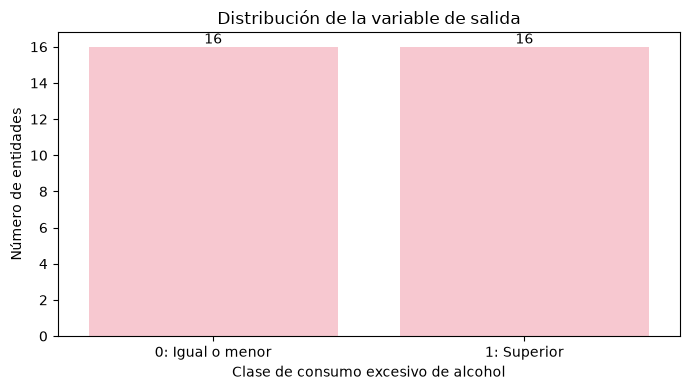

In [48]:
plt.figure(figsize=(7, 4))

ax = sns.countplot(data=data,x="AlcoholExcesivoAlto",color="pink")
ax.set_title("Distribución de la variable de salida")
ax.set_xlabel("Clase de consumo excesivo de alcohol")
ax.set_ylabel("Número de entidades")
ax.set_xticks([0, 1])
ax.set_xticklabels(["0: Igual o menor","1: Superior"])

for contenedor in ax.containers:
    ax.bar_label(contenedor)

plt.tight_layout()
plt.show()

[GRÁFICA 1]. Distribución de la variable de salida después del balance.

## Separación de entrenamiento y prueba
La base de datos se dividó en un conjunto de entrenamiento y un conjunto de prueba. El 70% de las observaciones se mantuvieron en entrenamiento, es decir, 22 estados. Mientras que el 30% restante se reservó para la prueba, correspondiente a 10 estados.

La separación se realizó de manera estratificada para conservar la proporción de ambas clases. En la Tabla 3, se observa que el conjunto de entrenamiento contiene 11 entidades de clase y el conjunto de prieba contiene 5 entidades de cada clase. Por ende, los datos originales, los datos de entrenamiento y los datos de prueba mantienen una distribución de 50% para la clase 0 y 50% para la clase 1.

Conservar este balance de clases permite que las métricas no estén controladas por una sola clase y facilita una comparación más justa entre el desempeño observado durante la validación cruzada y el obtenido posteriormente en el conjunto de prueba.

In [49]:
variables_X = ["PrevalenciaEnfermos","PrevalenciaPersonasEdad18","PrevalenciaFumadores","PrevalenciaSobrepesoObesidad"]
X = data[variables_X]
y = data["AlcoholExcesivoAlto"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=27,stratify=y)
print("Observaciones de entrenamiento:", len(X_train))
print("Observaciones de prueba:", len(X_test))

Observaciones de entrenamiento: 22
Observaciones de prueba: 10


In [50]:
def resumen_balance(nombre, salida):
    conteos = salida.value_counts().sort_index()
    proporciones = salida.value_counts(normalize=True).sort_index()
    return pd.DataFrame({"Conjunto": nombre,"Clase": conteos.index,"Frecuencia": conteos.values,"Porcentaje": proporciones.values * 100})

balance = pd.concat([resumen_balance("Datos originales", y),resumen_balance("Entrenamiento", y_train),resumen_balance("Prueba", y_test)], ignore_index=True)

balance.style.hide(axis="index").format({"Clase": "{:.0f}","Frecuencia": "{:.0f}","Porcentaje": "{:.2f}%"}).set_properties(**{"text-align": "center"}).set_table_styles([
    {"selector": "th","props": [("text-align", "center")]}]).set_caption("[TABLA 3]. Distribución y balance de clases en los conjuntos de datos.")

Conjunto,Clase,Frecuencia,Porcentaje
Datos originales,0,16,50.00%
Datos originales,1,16,50.00%
Entrenamiento,0,11,50.00%
Entrenamiento,1,11,50.00%
Prueba,0,5,50.00%
Prueba,1,5,50.00%


## Metodología de validación cruzada
Para estimar el desempeño esperado del modelo, se utilizó una validación cruzada estratificada de 5 folds, aplicada solamente al conjunto de entrenamiento. En cada iteración, cuatro folds se utilizaron para entrenar el modelo y el fold restante para validarlo. Este procedimiento se repitió 5 veces, utilizando en cada ocasión un fold diferente como conjunto de validación. 

Se utilizó un Pipeline que primero estandariza las variables y después ajusta una regresión logística. Incorporar la estandarización dentro del Pipeline evita una fuga de datos, debido a que los parámetros del escalamiento se calculan solamente con los datos de entrenamiento correspondientes a cada iteración. 

Las métricas seleccionadas fueron exactitud, precisión, sensibilidad, F1 Score y ROC-AUC. El uso de varias métricas permite describir de manera más completa el comportamiento del modelo.

Los resultados de la validación cruzada se observan en la Tabla 4. La validación cruzada obtuvo una exactitud promedio de 0.74, lo que indica que aproximadamente 74% de las observaciones de validación fueron clasificadas de manera correcta. La precisión fue de 0.7667, lo que muestra que casi el 77% de las predicciones realizadas como clase 1 fueorn correctas.

La sensibilidad promedio fue de 0.73, lo que indica que el modelo identificó aproximadamente el 73.33% de las entidades que realmente presentaban una prevalencia superior a la mediana. El F1 Score fue de 0.7267, lo que muestra un balance razonable entre precisión y sensibilidad. 

El ROC-AUC promeido fue de 0.7667, lo que indica que el modelo logró distinguir de manera razonable entre las dos clasesdurante la validación cruzada. Sin embargo, la Gráfica 2 muestra que el AUC cambia en los diferentes folds. Su desviación estándar fue de 0.1225, lo que indica que el modelo presenta variaciones dependiendo de los estados utilizados para entrenar y validar el modelo.

La validación cruzada proporciona una estimación más confiable que una sola división de datos, ya que se evalúa el modelo utilizando distintos subconjuntos. Estos resultados se deben interpretar con cuidado debido a la cantidad reducida de observaciones en la base de datos.

In [53]:
# Estandarización y regresión logística
pipeline_log = Pipeline(steps=[("scaler", StandardScaler()),("logistic", LogisticRegression(l1_ratio=0,max_iter=2000))])

# Validación cruzada estratificada de 5 folds
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=27)

# Métricas de evaluación
metricas = ["accuracy","precision","recall","f1","roc_auc"]

# Aplicar validación cruzada únicamente al entrenamiento
resultados_cv = cross_validate(pipeline_log,X_train,y_train,cv=cv,scoring=metricas,return_train_score=False)

# Tabla
tabla_cv = pd.DataFrame({"Métrica": ["Exactitud","Precisión","Sensibilidad","F1 Score","ROC-AUC"],"Promedio": [resultados_cv["test_accuracy"].mean(),resultados_cv["test_precision"].mean(),resultados_cv["test_recall"].mean(),resultados_cv["test_f1"].mean(),resultados_cv["test_roc_auc"].mean()],"Desviación estándar": [resultados_cv["test_accuracy"].std(),resultados_cv["test_precision"].std(),resultados_cv["test_recall"].std(),resultados_cv["test_f1"].std(),resultados_cv["test_roc_auc"].std()]})
tabla_cv.style.hide(axis="index").format({"Promedio": "{:.4f}","Desviación estándar": "{:.4f}"}).set_properties(**{"text-align": "center"}).set_table_styles([{"selector": "th","props": [("text-align", "center")]}]).set_caption("[TABLA 4]. Resultados de la validación cruzada estratificada.").background_gradient(subset=["Promedio"],cmap="RdPu")

Métrica,Promedio,Desviación estándar
Exactitud,0.7400,0.1463
Precisión,0.7667,0.2000
Sensibilidad,0.7333,0.2261
F1 Score,0.7267,0.1665
ROC-AUC,0.7667,0.1225


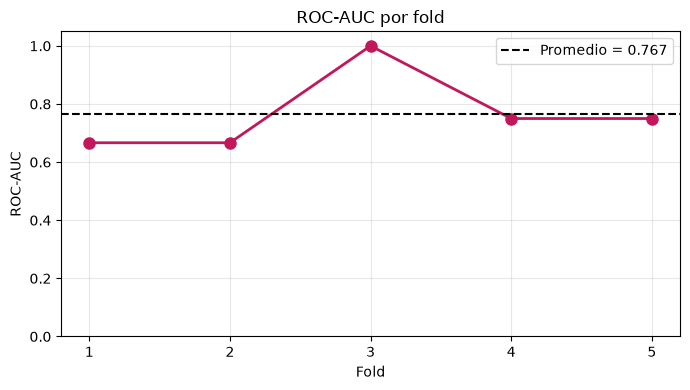

In [54]:
auc_scores = resultados_cv["test_roc_auc"]

plt.figure(figsize=(7, 4))
plt.plot(range(1, 6),auc_scores,marker="o",markersize=8,linewidth=2,color="#C2185B")

plt.axhline(auc_scores.mean(),color="black",linestyle="--",label=f"Promedio = {auc_scores.mean():.3f}")

plt.title("ROC-AUC por fold")
plt.xlabel("Fold")
plt.ylabel("ROC-AUC")
plt.xticks(range(1, 6))
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

[GRÁFICA 2]. Gráfica de ROC_AUC por fold.

## Entrenamiento final y matriz de confusión
Después de la validación cruzada, se entrenó un modelo final utilizando las 22 observaciones del conjunto de entrenamiento. Posteriormente, se calcularon las probabilidades de pertenecer a la clase 1 para las 10 entidades del conjunto de prueba, esto se demuestra en la Tabla 1. Con un umbral de decisión de 0.50, las probabilidades iguales o superiores a este valor se clasificaron como clase 1 y las probabilidades inferiores como clase 0. 

En la Gráfica 3, se muestra la matriz de confusión, donde se enseña que el modelo obtuvo 2 verdaderos positivos, 2 verdaderos negativos, 3 falsos positivos y 3 falsos negativos. Por lo que, solamente 4 de las 10 entidades fueron clasificados de manera correcta. 

En la Tabla 6, se muestra que la exactitud, precisión, sensibilidad, especifidad y F1 Score fueron de 0.4. El ROC_AUC fue de 0.36, lo que significa que el modelo tuvo dificultades para diferenciar correctamente entre las dos clases en el conjunto de prueba.

In [55]:
# Entrenar con todos los datos de entrenamiento
pipeline_log.fit(X_train,y_train)

# Probabilidad de pertenecer a la clase 1
probabilidades_test = pipeline_log.predict_proba(X_test)[:,1]

# Predicción usando el umbral de 0.50
predicciones_test = (probabilidades_test >= 0.50).astype(int)

# Tabla
tabla_predicciones = pd.DataFrame({"Valor real": y_test.values,"Probabilidad clase 1": probabilidades_test,"Clase predicha": predicciones_test})

tabla_predicciones.style.hide(axis="index").format({"Valor real": "{:.0f}","Probabilidad clase 1": "{:.4f}","Clase predicha": "{:.0f}"}).set_properties(**{"text-align": "center"}).set_table_styles([{"selector": "th","props": [("text-align", "center")]}]).set_caption("[TABLA 5]. Predicciones obtenidas en el conjunto de prueba.").background_gradient(subset=["Probabilidad clase 1"],cmap="RdPu")

Valor real,Probabilidad clase 1,Clase predicha
0,0.7817,1
1,0.3847,0
1,0.6042,1
1,0.4803,0
0,0.4118,0
1,0.4707,0
1,0.5855,1
0,0.6689,1
0,0.1424,0
0,0.6620,1


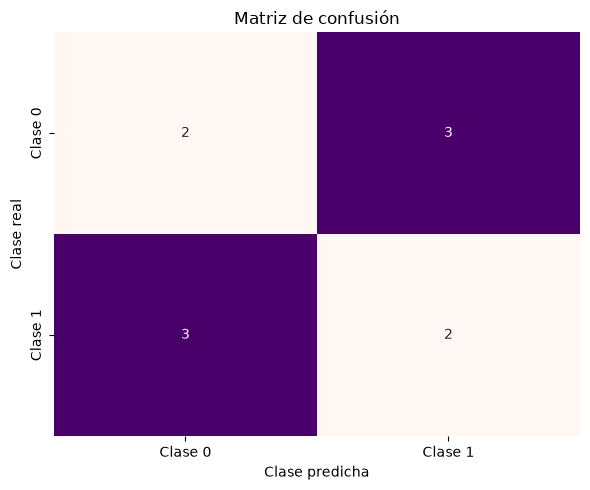

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

matriz = confusion_matrix(y_test,predicciones_test,labels=[0, 1])
plt.figure(figsize=(6, 5))
sns.heatmap(matriz,annot=True,fmt="d",cmap="RdPu",cbar=False,xticklabels=["Clase 0", "Clase 1"],yticklabels=["Clase 0", "Clase 1"])

plt.title("Matriz de confusión")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

[GRÁFICA 3]. Matriz de confusión.

In [57]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

# Elementos de la matriz de confusión
tn,fp,fn,tp = matriz.ravel()

# Métricas
accuracy = accuracy_score(y_test,predicciones_test)
precision = precision_score(y_test,predicciones_test,zero_division=0)
sensibilidad = recall_score(y_test,predicciones_test,zero_division=0)
especificidad = tn/(tn+fp)
f1 = f1_score(y_test,predicciones_test,zero_division=0)
auc = roc_auc_score(y_test,probabilidades_test)

# Tabla de resultados
tabla_prueba = pd.DataFrame({"Métrica": ["Exactitud","Precisión","Sensibilidad","Especificidad","F1 Score","ROC-AUC"],"Resultado": [accuracy,precision,sensibilidad,especificidad,f1,auc]})

tabla_prueba.style.hide(axis="index").format({"Resultado": "{:.4f}"}).set_properties(**{"text-align": "center"}).set_table_styles([{"selector": "th","props": [("text-align", "center")]}]).set_caption("[TABLA 6]. Desempeño del modelo en el conjunto de prueba.").background_gradient(subset=["Resultado"],cmap="RdPu")

Métrica,Resultado
Exactitud,0.4000
Precisión,0.4000
Sensibilidad,0.4000
Especificidad,0.4000
F1 Score,0.4000
ROC-AUC,0.3600


## Comparación entre validación cruzada y prueba
Como ya se había discutido prevamiente, los resultados de validación cruzada fueron considerablemente superiores a los obtenidos en el conjunto de prueba. Esta comparación se muestra en la Tabla 7, donde se puede observar de manera clara que las métricas seleccionadas bajaron significativamente en valor. 

La exactitud disminuyó de 0.74 a 0.4, la precisión bajó de 0.7667 a 0.4, la sensibilidad y la especificidad disminuyeron de 0.7333 a 0.4, y el F1 Score bajó de 0.7267 a 0.4. La diferencia más importante se observa en el ROC-AUC, que disminuyó de 0.7667 durante la validación cruzada a 0.36 en el conjunto de prueba. Por lo tanto, el desempeño favorable observado durante la validación cruzada no se mantuvo al evaluar el modelo con observaciones independientes.

Esto se puede explicar por el tamaño reducido de la base. El conjunto de prueba contiene solamente 10 datos, por lo que los resultados presentan una alta sensibilidad a la selección de los conjuntos de entrenamiento y prueba.

In [58]:
from sklearn.metrics import make_scorer

# Calcular especificidad en validación cruzada
resultado_especificidad_cv = cross_validate(pipeline_log,X_train,y_train,cv=cv,scoring=make_scorer(recall_score,pos_label=0,zero_division=0),return_train_score=False)

# Resultados promedio de validación cruzada
promedios_cv = [resultados_cv["test_accuracy"].mean(),resultados_cv["test_precision"].mean(),resultados_cv["test_recall"].mean(),resultado_especificidad_cv["test_score"].mean(),resultados_cv["test_f1"].mean(),resultados_cv["test_roc_auc"].mean()]

# Resultados del conjunto de prueba
resultados_prueba = [accuracy,precision,sensibilidad,especificidad,f1,auc]

# Tabla
tabla_comparacion = pd.DataFrame({"Métrica": ["Exactitud","Precisión","Sensibilidad","Especificidad","F1 Score","ROC-AUC"],"Validación cruzada": promedios_cv,"Prueba independiente": resultados_prueba})

tabla_comparacion.style.hide(axis="index").format({"Validación cruzada": "{:.4f}","Prueba independiente": "{:.4f}"}).set_properties(**{"text-align": "center"}).set_table_styles([{"selector": "th","props": [("text-align", "center")]}]).set_caption("[TABLA 7]. Comparación entre la validación cruzada y el conjunto de prueba.").background_gradient(subset=["Validación cruzada","Prueba independiente"],cmap="RdPu")

Métrica,Validación cruzada,Prueba independiente
Exactitud,0.7400,0.4000
Precisión,0.7667,0.4000
Sensibilidad,0.7333,0.4000
Especificidad,0.7333,0.4000
F1 Score,0.7267,0.4000
ROC-AUC,0.7667,0.3600


## Análisis de los umbrales
El umbral de decisión establece la probabilidad mínima necesaria para clasificar una entidad como perteneciente a la clase 1. Al disminuir el umbral, una mayor cantidad de estados se clasifica como positiva. Por lo que se aumenta la sensibilidad, debido a que se identifican más entidades con consumo superior a la mediana, pero también incrementan los falsos positivos y, por ende, se reduce la especificidad.

Por el otro lado, al aumentar el umbral se requiere una probabilidad mayor para asignar la clase 1. Esto puede mejorar la especificidad al reducir los falsos positivos, pero también produce más falsos negativos y disminuye la sensibilidad.

La Tabla 8 demuestra estos efectos en los cambios del valor del umbral, lo que causa este cambio en sensibilidad y especificidad. Sin embargo, ningún umbral produce simultáneamente valores elevados y equilibrados en todas las métricas. Por esta razón, modificar el umbral no soluciona completamente las limitaciones predictivas del modelo. 

La elección final dependería de lo que se busca lograr. Si fuera más importante identificar la mayor cantidad posible de entidades con consumo superior a la mediana, se utilizaría un umbral menor. Si se buscara evitar clasificar incorrectamente como alta a una entidad de clase 0, sería conveniente utilizar un umbral mayor.

In [59]:
umbrales = np.arange(0.10,0.91,0.05)
resultados_umbrales = []

for umbral_decision in umbrales:
    pred_umbral = (probabilidades_test >= umbral_decision).astype(int)
    matriz_umbral = confusion_matrix(y_test,pred_umbral,labels=[0,1])
    tn,fp,fn,tp = matriz_umbral.ravel()
    exactitud_umbral = accuracy_score(y_test,pred_umbral)
    precision_umbral = precision_score(y_test,pred_umbral,zero_division=0)
    sensibilidad_umbral = recall_score(y_test,pred_umbral,zero_division=0)
    especificidad_umbral = tn/(tn+fp) if (tn+fp)>0 else 0
    f1_umbral = f1_score(y_test,pred_umbral,zero_division=0)
    resultados_umbrales.append({"Umbral": umbral_decision,"Exactitud": exactitud_umbral,"Precisión": precision_umbral,"Sensibilidad": sensibilidad_umbral,"Especificidad": especificidad_umbral,"F1 Score": f1_umbral})

tabla_umbrales = pd.DataFrame(resultados_umbrales)

tabla_umbrales.style.hide(axis="index").format({"Umbral": "{:.2f}","Exactitud": "{:.3f}","Precisión": "{:.3f}","Sensibilidad": "{:.3f}","Especificidad": "{:.3f}","F1 Score": "{:.3f}"}).set_properties(**{"text-align": "center"}).set_table_styles([{"selector": "th","props": [("text-align", "center")]}]).set_caption("[TABLA 8]. Desempeño del modelo para diferentes umbrales de decisión.").background_gradient(subset=["Exactitud","Precisión","Sensibilidad","Especificidad","F1 Score"],cmap="RdPu")

Umbral,Exactitud,Precisión,Sensibilidad,Especificidad,F1 Score
0.10,0.500,0.500,1.000,0.000,0.667
0.15,0.600,0.556,1.000,0.200,0.714
0.20,0.600,0.556,1.000,0.200,0.714
0.25,0.600,0.556,1.000,0.200,0.714
0.30,0.600,0.556,1.000,0.200,0.714
0.35,0.600,0.556,1.000,0.200,0.714
0.40,0.500,0.500,0.800,0.200,0.615
0.45,0.600,0.571,0.800,0.400,0.667
0.50,0.400,0.400,0.400,0.400,0.400
0.55,0.400,0.400,0.400,0.400,0.400


## Curva ROC
La curva ROC muestra la relación entre la tasa de verdaderos positivos, o sensibilidad, y la tasa de falsos positivos, equivalente a uno menos la especificidad, para todos los posibles umbrales de clasificación. Esto se muestra de manera gráfica en la Gráfica 4.

El área bajo la curva obtenida en el conjunto de prueba fue de 0.3600. Como este resultado es menor a 0.50, el modelo tuvo dificultades para distinguir correctamente entre las dos clases. Esto demuestra que el bajo desempeño no se debe solamente al umbral de 0.50, sino también a que las probabilidades calculadas por el modelo no separan de manera adecuada a las entidades.

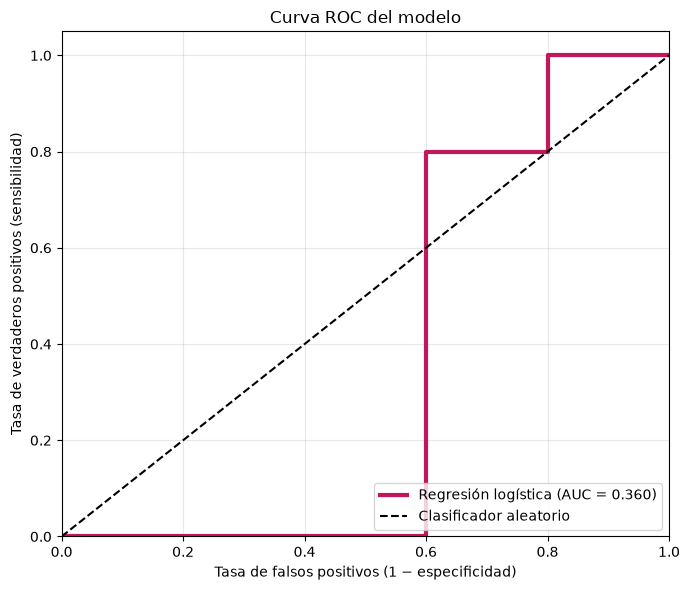

Área bajo la curva (AUC): 0.3600


In [60]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, umbrales_roc = roc_curve(y_test,probabilidades_test)
auc_prueba = roc_auc_score(y_test,probabilidades_test)

plt.figure(figsize=(7, 6))
plt.plot(fpr,tpr,color="#C2185B",linewidth=3,label=f"Regresión logística (AUC = {auc_prueba:.3f})")

plt.plot([0, 1],[0, 1],color="black",linestyle="--",label="Clasificador aleatorio")

plt.title("Curva ROC del modelo")
plt.xlabel("Tasa de falsos positivos (1 − especificidad)")
plt.ylabel("Tasa de verdaderos positivos (sensibilidad)")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Área bajo la curva (AUC): {auc_prueba:.4f}")

[GRÁFICA 4]. Curva ROC del modelo.

## Interpretación de coeficientes
Los coeficientes de la regresión logística representan cambios en el logaritmo de los momios de pertenecer a la clase 1. Debido a que las variables fueron estandarizadas, cada resultado representa el efecto asociado con el aumento de una desviación estándar en el predictor correspondiente, manteniendo constantes las demás variables. Esto se demuestra en la Tabla 9.

La prevalencia de personas mayores de 18 años presentó el efecto positivo de mayor magnitud, con un coeficiente de 0.8031 y un odds ratio de 2.2324. Esto indica que un aumento de una desviación estándar en esta variable multiplica aproximadamente por 2.23 los odds de pertenecer a la clase 1. La prevalencia de fumadores obtuvo un coeficiente de 0.5404 y un odds ratio de 1.7167, equivalente a un incremento de 71.67 % en los odds. La prevalencia de sobrepeso u obesidad también presentó una asociación positiva, con un odds ratio de 1.4515 y un aumento de 45.15 % en los odds. Por otro lado, la prevalencia de enfermos presentó un coeficiente negativo de −0.2715 y un odds ratio de 0.7622. Esto representa una disminución aproximada de 23.78 % en los odds de pertenecer a la clase 1.

Estas relaciones corresponden a asociaciones estadísticas identificadas por el modelo y no demuestran causalidad. Además, debido al tamaño reducido de la muestra y al bajo desempeño en prueba, los coeficientes deben interpretarse de manera cuidadosa.

In [61]:
# Extraer el modelo logístico
modelo_logistico = pipeline_log.named_steps["logistic"]

# Coeficientes y odds ratios
coeficientes = modelo_logistico.coef_[0]
odds_ratios = np.exp(coeficientes)

# Tabla
tabla_coeficientes = pd.DataFrame({"Variable": variables_X,"Coeficiente": coeficientes,"Odds ratio": odds_ratios})

tabla_coeficientes["Dirección del efecto"] = np.where(tabla_coeficientes["Coeficiente"]>0,"Aumenta la probabilidad","Disminuye la probabilidad")
tabla_coeficientes["Cambio porcentual en odds"] = (tabla_coeficientes["Odds ratio"]-1)*100
tabla_coeficientes = tabla_coeficientes.sort_values("Odds ratio",ascending=False)

tabla_coeficientes.style.hide(axis="index").format({"Coeficiente": "{:.4f}","Odds ratio": "{:.4f}","Cambio porcentual en odds": "{:.2f}%"}).set_properties(**{"text-align": "center"}).set_table_styles([{"selector": "th","props": [("text-align", "center")]}]).set_caption("[TABLA 9]. Coeficientes y odds ratios del modelo de regresión logística.").background_gradient(subset=["Odds ratio"],cmap="RdPu")

Variable,Coeficiente,Odds ratio,Dirección del efecto,Cambio porcentual en odds
PrevalenciaPersonasEdad18,0.8031,2.2324,Aumenta la probabilidad,123.24%
PrevalenciaFumadores,0.5404,1.7167,Aumenta la probabilidad,71.67%
PrevalenciaSobrepesoObesidad,0.3726,1.4515,Aumenta la probabilidad,45.15%
PrevalenciaEnfermos,-0.2715,0.7622,Disminuye la probabilidad,-23.78%


## Conclusiones y limitaciones
La transformación de la prevalencia de consumo excesivo de alcohol en una variable binaria permitió plantear un problema de clasificación equilibrado. El uso de la mediana como punto de corte elaboró dos clases con 16 entidades cada una, mientras que la separación estratificada conservó este balance en los conjuntos de entrenamiento y prueba.

La regresión logística presentó un desempeño aceptable durante la validación cruzada, con una exactitud promedio de 0.7400 y un ROC-AUC de 0.7667. Sin embargo, estos resultados no se mantuvieron en el conjunto de prueba independiente, donde la exactitud fue de 0.4000 y el ROC-AUC de 0.3600. Por lo que no existe evidencia suficiente para afirmar que el modelo pueda generalizar de manera confiable a entidades no utilizadas durante su entrenamiento.

Los coeficientes sugieren que la proporción de adultos, la prevalencia de fumadores y la prevalencia de sobrepeso u obesidad aumentan la probabilidad estimada de pertenecer al grupo con consumo superior a la mediana. La prevalencia de enfermos mostró una relación negativa.

Como trabajo futuro, sería conveniente incorporar información de diferentes años, utilizar observaciones municipales o individuales, incluir variables sociales y económicas y comparar la regresión logística con otros métodos de clasificación. También podría aplicarse validación cruzada repetida para obtener estimaciones más estables del desempeño.

## Bibliografía
Secretaría de Salud. (2022, 29 de diciembre). Uso nocivo de bebidas alcohólicas, asociado con más de 200 problemas de salud física y mental. Gobierno de México. https://www.gob.mx/salud/prensa/598-uso-nocivo-de-bebidas-alcoholicas-asociado-con-mas-de-200-problemas-de-salud-fisica-y-mental